# Smart Household Energy Consumption Analytics & Forecasting
### End-to-End IoT Telemetry Processing, Exploratory Analytics, SQL Queries & Machine Learning Forecasting

---

## 1. Project Overview & Objectives

Smart meters and appliance-level sub-metering devices continuously record high-frequency electrical telemetry. This project implements a complete, end-to-end analytical and machine-learning pipeline based on the **UCI Individual Household Electric Power Consumption dataset** (2,075,259 one-minute observations recorded over nearly four years from December 2006 through November 2010).

> **IoT Setting Note:** This dataset comprises historical telemetry recorded by residential metering equipment. It represents historical IoT meter data rather than a streaming sensor deployment. No real-time deployment is included or claimed.

### Primary Objectives:
1. **Data Ingestion & Understanding:** Ingest over 2 million 1-minute smart meter readings, profile schema properties, detect missing measurement intervals, and verify temporal ordering.
2. **Causal, Time-Aware Preprocessing:** Impute short gaps via time-based linear interpolation and multi-day outages via historical weekly profile matching (strictly past data to avoid future lookahead leakage).
3. **Physical Energy Conversion & Aggregation:** Convert instantaneous active power ($kW$) to active electrical energy ($kWh$) and aggregate observations to **Hourly**, **Daily**, and **Monthly** levels.
4. **Exploratory Data Analysis (EDA):** Identify seasonal trends, diurnal load shapes, weekend consumption premiums, voltage stability, and appliance sub-meter contributions.
5. **Relational SQL Analytics (SQLite):** Execute operational queries using SQL window functions (`LAG()`, `RANK()`, moving averages) on aggregated tables.
6. **Feature Engineering & Leakage Verification:** Generate lag features, rolling statistics, and calendar attributes with zero-leakage verification.
7. **Predictive Modeling:** Train and evaluate multiple models (**Naive Baseline**, **Linear Regression**, **Random Forest Regressor**, and **XGBoost Regressor**) on a strict chronological 80/20 split.
8. **Operational Sensitivity Analysis & Evaluation:** Evaluate models using MAE, RMSE, R², and MAPE, including sensitivity analysis excluding heavily imputed days.
9. **Multi-Step Recursive Forecasting:** Generate a 7-day ahead daily consumption forecast using the top-performing model.
10. **Business Insights & Decision Support:** Provide actionable demand management and efficiency recommendations.


## 2. Environment and Libraries

We configure the Python environment, establish robust dynamic path resolution so the notebook runs seamlessly whether executed from the project root, a nested workspace, or the `notebooks` directory, and import necessary libraries for data processing, database querying, visualization, and machine learning.


In [1]:
import sys
import os
import json
import sqlite3
import warnings
from pathlib import Path

# Scientific and data processing libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# Gradient boosting
import xgboost as xgb
from xgboost import XGBRegressor

# Joblib for model persistence
import joblib

# Suppress minor warnings for clean display
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Dynamic Project Root Resolution
def get_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src" / "config.py").exists():
            return candidate
        if (candidate / "Smart-Household-Energy-Analytics" / "src" / "config.py").exists():
            return (candidate / "Smart-Household-Energy-Analytics").resolve()
    raise FileNotFoundError("Could not resolve project root directory containing src/config.py")

PROJECT_ROOT = get_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import config as cfg
import data_cleaning as dc
import eda
import sql_analysis
import forecasting as fc

# Crucial: restore inline matplotlib backend after importing src modules that set Agg
%matplotlib inline

# Configure plotting aesthetics
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Python Executable: {sys.executable}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"XGBoost Version: {xgb.__version__}")


Project Root: D:\Smart Energy Monitoring\Final Output\Smart-Household-Energy-Analytics\Smart-Household-Energy-Analytics
Python Executable: C:\Users\aksha\AppData\Local\Python\pythoncore-3.14-64\python.exe
Pandas Version: 3.0.6
Scikit-Learn Version: 1.9.1
XGBoost Version: 3.4.1


## 3. Dataset Description & Architecture

The dataset is sourced from the **UCI Machine Learning Repository** (*Individual Household Electric Power Consumption*):

| Column Name | Data Type | Physical Unit | Description & Details |
| :--- | :--- | :--- | :--- |
| `Date` | String | dd/mm/yyyy | Calendar date of observation |
| `Time` | String | hh:mm:ss | Timestamp of observation (1-minute resolution) |
| `Global_active_power` | Numeric | kW | Household global minute-averaged active power |
| `Global_reactive_power` | Numeric | kW | Household global minute-averaged reactive power |
| `Voltage` | Numeric | V | Minute-averaged line voltage |
| `Global_intensity` | Numeric | A | Minute-averaged current intensity |
| `Sub_metering_1` | Numeric | Wh | Energy sub-meter No. 1: Kitchen appliances (dishwasher, microwave) |
| `Sub_metering_2` | Numeric | Wh | Energy sub-meter No. 2: Laundry room (washing machine, tumble dryer, refrigerator) |
| `Sub_metering_3` | Numeric | Wh | Energy sub-meter No. 3: Electric water heater & air conditioner |

### Physical Energy Relationship:
1. **Instantaneous Active Power to Energy Conversion:**
   $$\text{Energy (kWh)} = \frac{\text{Global\_active\_power (kW)}}{60}$$
2. **Unmetered Energy Calculation:**
   $$\text{Other\_Wh} = \left(\text{Global\_active\_power} \times \frac{1000}{60}\right) - \sum_{k=1}^3 \text{Sub\_metering\_}k$$


## 4. Data Loading & Profiling

We load the raw CSV file `household_power_consumption.csv` located in `data/raw/`. The raw file uses the question mark `?` to signify missing sensor telemetry. We parse `?` as `NaN` and inspect data volume, memory usage, missingness, and boundary dates.


In [2]:
# Verify raw file presence
raw_path = cfg.RAW_FILE
if not raw_path.exists():
    alt = PROJECT_ROOT.parent / "household_power_consumption.csv"
    if alt.exists():
        raw_path = alt

print(f"Loading raw dataset from: {raw_path}")
print(f"File size: {raw_path.stat().st_size / (1024*1024):.2f} MB")

# Read initial sample and examine raw format
df_sample = pd.read_csv(raw_path, nrows=5)
display(df_sample)


Loading raw dataset from: D:\Smart Energy Monitoring\Final Output\Smart-Household-Energy-Analytics\Smart-Household-Energy-Analytics\data\raw\household_power_consumption.csv
File size: 105.21 MB


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
# Load data quality profile generated from raw ingestion
profile_path = cfg.PROCESSED_DIR / "data_quality_report.json"
if profile_path.exists():
    with open(profile_path, "r") as f:
        data_quality = json.load(f)
    prof = data_quality["profile"]
else:
    raw_df = dc.load_raw(raw_path)
    prof = dc.profile_raw(raw_df, raw_path)

print("=" * 60)
print("RAW DATASET INGESTION PROFILE")
print("=" * 60)
print(f"Total Rows Ingested     : {prof['rows']:,}")
print(f"Total Columns          : {prof['columns']}")
print(f"Date Range Start       : {prof['date_range_start']}")
print(f"Date Range End         : {prof['date_range_end']}")
print(f"Unique Calendar Dates  : {prof['unique_dates']}")
print(f"Duplicate Full Rows    : {prof['duplicate_full_rows']}")
print(f"Duplicate Timestamps   : {prof['duplicate_timestamps']}")
print(f"Days with 1,440 Obs    : {prof['days_with_1440_obs']}")
print(f"Incomplete Edge Days   : {prof['days_with_fewer_than_1440_obs']}")
print("\nMissing Value Breakdown:")
for col, cnt in prof['missing_values_per_column'].items():
    pct = (cnt / prof['rows']) * 100
    print(f"  - {col:<25}: {cnt:>7,} missing ({pct:.2f}%)")


RAW DATASET INGESTION PROFILE
Total Rows Ingested     : 2,075,259
Total Columns          : 9
Date Range Start       : 2006-12-16 17:24:00
Date Range End         : 2010-11-26 21:02:00
Unique Calendar Dates  : 1442
Duplicate Full Rows    : 0
Duplicate Timestamps   : 0
Days with 1,440 Obs    : 1440
Incomplete Edge Days   : 2

Missing Value Breakdown:
  - Date                     :       0 missing (0.00%)
  - Time                     :       0 missing (0.00%)
  - Global_active_power      :  25,979 missing (1.25%)
  - Global_reactive_power    :  25,979 missing (1.25%)
  - Voltage                  :  25,979 missing (1.25%)
  - Global_intensity         :  25,979 missing (1.25%)
  - Sub_metering_1           :  25,979 missing (1.25%)
  - Sub_metering_2           :  25,979 missing (1.25%)
  - Sub_metering_3           :  25,979 missing (1.25%)


## 5. Data Cleaning & Preprocessing

### Preprocessing Strategy & Decisions:
1. **Timestamp Uniformity:** Combine `Date` and `Time` into a contiguous 1-minute `DateTime` index. 
2. **Missing Sensor Readings:** The 25,979 missing readings occur synchronously across all 7 measurement columns across **71 discrete gap intervals**.
   - **Short Gaps ($\le$ 3 hours / 180 minutes):** 64 gaps (441 minutes total) are imputed via **time-based linear interpolation** (`Imputation_Flag = 1`).
   - **Long Outage Gaps (> 3 hours):** 7 gaps (25,538 minutes total, max gap ~5 days) represent prolonged equipment outages. Interpolating across days would draw unrealistic flat lines; therefore, they are imputed using the **historical weekly profile**—the average of the identical minute from 1 to 4 weeks *earlier* (`Imputation_Flag = 2`). Strictly past data is used to ensure no forward-looking data leakage.
3. **Outlier Preservation:** Extreme spikes in `Global_active_power` (up to 11.12 kW) reflect genuine high-draw appliance loads (e.g., simultaneous water heating and oven use) rather than sensor faults, and are preserved.
4. **Boundary Truncation:** The first day (2006-12-16, starts 17:24) and final day (2010-11-26, ends 21:02) are partial calendar days and are excluded from daily/hourly/monthly aggregations, leaving exactly **1,440 complete contiguous calendar days**.


In [4]:
# Execute or load cleaned temporal aggregations
daily_csv = cfg.POWERBI_DIR / "daily_energy.csv"
hourly_csv = cfg.POWERBI_DIR / "hourly_energy.csv"
monthly_csv = cfg.POWERBI_DIR / "monthly_energy.csv"

if not (daily_csv.exists() and hourly_csv.exists() and monthly_csv.exists()):
    print("Executing data cleaning pipeline...")
    dc.run()
else:
    print("Cleaned tables verified in outputs/powerbi/")

daily_df = pd.read_csv(daily_csv, parse_dates=["Date"])
hourly_df = pd.read_csv(hourly_csv, parse_dates=["DateTime"])
monthly_df = pd.read_csv(monthly_csv, parse_dates=["MonthStart"])

print(f"Daily Aggregation   : {daily_df.shape[0]} days, {daily_df.shape[1]} features")
print(f"Hourly Aggregation  : {hourly_df.shape[0]} hours, {hourly_df.shape[1]} features")
print(f"Monthly Aggregation : {monthly_df.shape[0]} months, {monthly_df.shape[1]} features")
print(f"Contiguous Daily Date Span: {daily_df['Date'].min().strftime('%Y-%m-%d')} to {daily_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Heavily Imputed Days (>= 6 hours filled): {daily_df['Is_Heavily_Imputed'].sum()}")


Cleaned tables verified in outputs/powerbi/
Daily Aggregation   : 1440 days, 22 features
Hourly Aggregation  : 34560 hours, 18 features
Monthly Aggregation : 48 months, 14 features
Contiguous Daily Date Span: 2006-12-17 to 2010-11-25
Heavily Imputed Days (>= 6 hours filled): 21


In [5]:
# Display sample rows from each aggregated level
print("--- Daily Table Sample (head 3) ---")
display(daily_df[['Date', 'Daily_Energy_kWh', 'Sub_metering_1_kWh', 'Sub_metering_2_kWh', 'Sub_metering_3_kWh', 'Other_kWh', 'Avg_Voltage', 'Day_Name', 'Is_Heavily_Imputed']].head(3))

print("--- Hourly Table Sample (head 3) ---")
display(hourly_df[['DateTime', 'Hourly_Energy_kWh', 'Avg_Active_Power_kW', 'Avg_Voltage', 'Hour', 'Day_Type']].head(3))

print("--- Monthly Table Sample (head 3) ---")
display(monthly_df[['Month', 'Monthly_Energy_kWh', 'Avg_Daily_Energy_kWh', 'Days_In_Data', 'Is_Full_Month']].head(3))


--- Daily Table Sample (head 3) ---


,Date,Daily_Energy_kWh,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh,Other_kWh,Avg_Voltage,Day_Name,Is_Heavily_Imputed
0,2006-12-17,56.50767,2.033,4.187,13.341,36.94667,240.08703,Sunday,0
1,2006-12-18,36.73043,1.063,2.621,14.018,19.02843,241.23169,Monday,0
2,2006-12-19,27.76990,0.839,7.602,6.197,13.13190,241.99931,Tuesday,0


--- Hourly Table Sample (head 3) ---


,DateTime,Hourly_Energy_kWh,Avg_Active_Power_kW,Avg_Voltage,Hour,Day_Type
0,2006-12-17 00:00:00,1.88247,1.88247,240.96183,0,Weekend
1,2006-12-17 01:00:00,3.34940,3.34940,240.44833,1,Weekend
2,2006-12-17 02:00:00,1.58727,1.58727,245.81867,2,Weekend


--- Monthly Table Sample (head 3) ---


,Month,Monthly_Energy_kWh,Avg_Daily_Energy_kWh,Days_In_Data,Is_Full_Month
0,2006-12,676.96050,45.13070,15,0
1,2007-01,1150.28827,37.10607,31,1
2,2007-02,941.61380,33.62906,28,1


## 6. Exploratory Data Analysis (EDA)

We explore energy consumption patterns across multiple temporal granularities:
1. Long-term multi-year consumption trajectory and 30-day moving average.
2. Monthly energy trends distinguishing complete calendar months.
3. Diurnal (hourly) load curve contrasting weekdays and weekends.
4. Day-of-week consumption distributions and weekend premium.
5. Appliance-level sub-meter load shares (kitchen, laundry, water heating/AC, unmetered).
6. Voltage stability and instantaneous power distributions.
7. Pearson correlation heatmap across daily telemetry features.
8. Top 10 highest and lowest consumption days.
9. Seasonal heatmaps across calendar years and months.


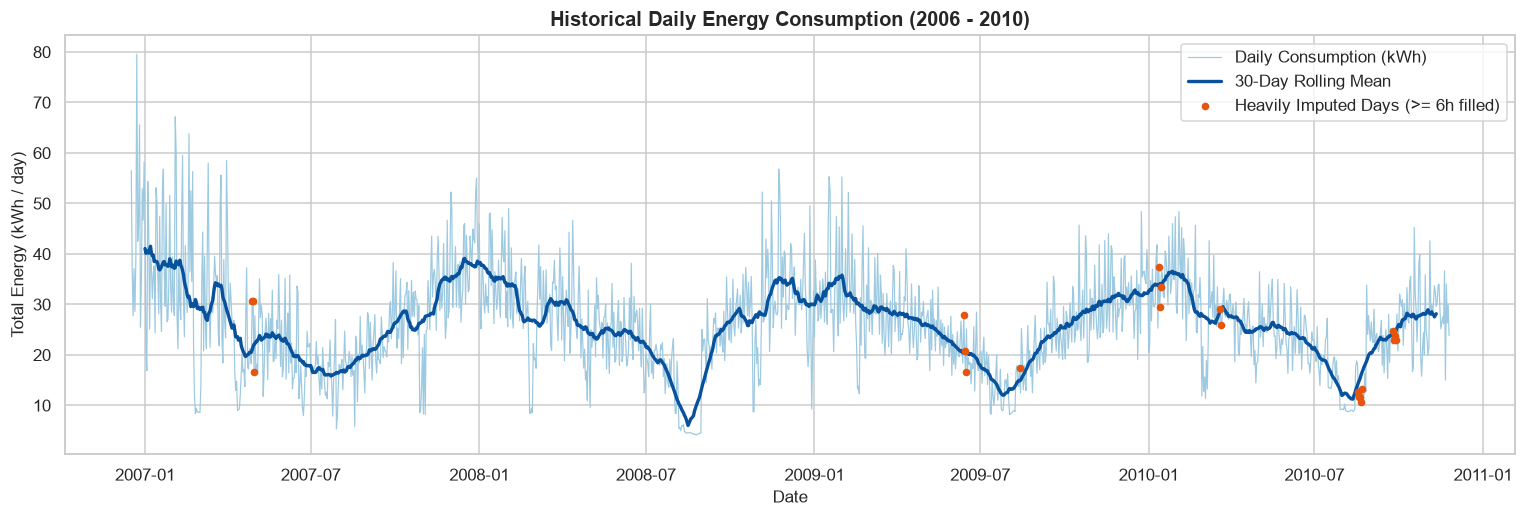

In [6]:
# Visualization 1: Daily Consumption Trend with 30-Day Moving Average
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(daily_df["Date"], daily_df["Daily_Energy_kWh"], lw=0.8, color="#9ecae1", label="Daily Consumption (kWh)")
ax.plot(daily_df["Date"], daily_df["Daily_Energy_kWh"].rolling(30, center=True).mean(), 
        lw=2.2, color="#08519c", label="30-Day Rolling Mean")

heavy_mask = daily_df["Is_Heavily_Imputed"] == 1
ax.scatter(daily_df.loc[heavy_mask, "Date"], daily_df.loc[heavy_mask, "Daily_Energy_kWh"], 
           s=16, color="#e6550d", zorder=3, label="Heavily Imputed Days (>= 6h filled)")

ax.set_title("Historical Daily Energy Consumption (2006 - 2010)", fontsize=13, fontweight='bold')
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Total Energy (kWh / day)", fontsize=11)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


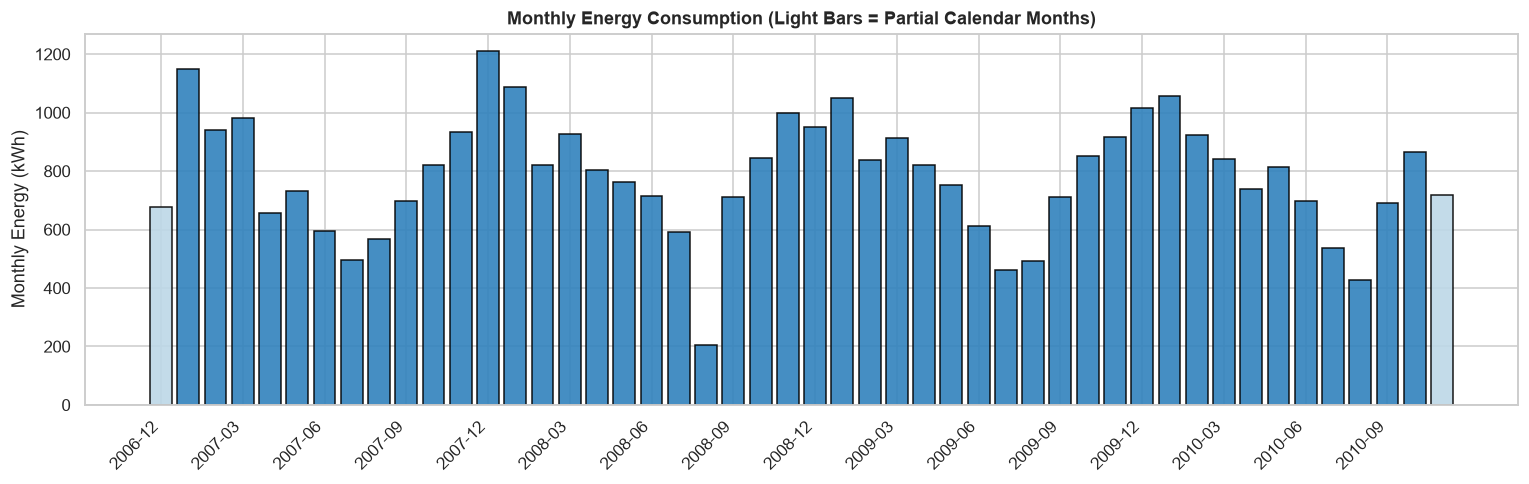

In [7]:
# Visualization 2: Monthly Energy Consumption Trend
fig, ax = plt.subplots(figsize=(14, 4.5))
colors_m = np.where(monthly_df["Is_Full_Month"] == 1, "#3182bd", "#bdd7e7")
ax.bar(monthly_df["Month"], monthly_df["Monthly_Energy_kWh"], color=colors_m, edgecolor="black", alpha=0.9)
ax.set_xticks(range(0, len(monthly_df), 3))
ax.set_xticklabels(monthly_df["Month"].iloc[::3], rotation=45, ha="right")
ax.set_title("Monthly Energy Consumption (Light Bars = Partial Calendar Months)", fontsize=12, fontweight='bold')
ax.set_ylabel("Monthly Energy (kWh)")
plt.tight_layout()
plt.show()


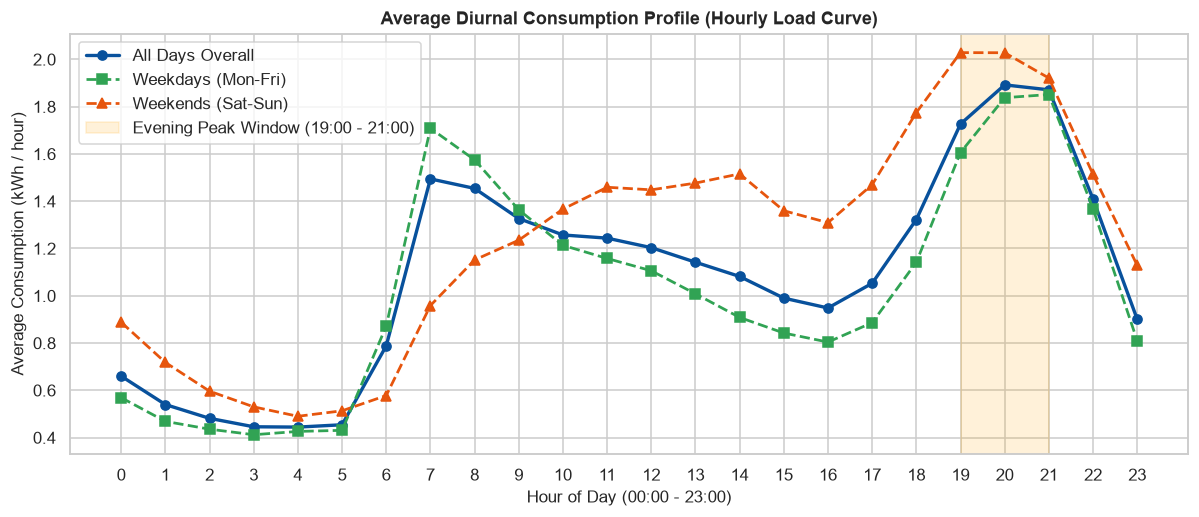

Diurnal Peak  : Hour 20:00 (1.89 kWh/hr)
Diurnal Trough: Hour 4:00 (0.44 kWh/hr)


In [8]:
# Visualization 3: Hourly Diurnal Profile by Day Type
fig, ax = plt.subplots(figsize=(11, 4.8))
hourly_all = hourly_df.groupby("Hour")["Hourly_Energy_kWh"].mean()
hourly_wkday = hourly_df[hourly_df["Day_Type"] == "Weekday"].groupby("Hour")["Hourly_Energy_kWh"].mean()
hourly_wkend = hourly_df[hourly_df["Day_Type"] == "Weekend"].groupby("Hour")["Hourly_Energy_kWh"].mean()

ax.plot(hourly_all.index, hourly_all.values, marker="o", lw=2.2, color="#08519c", label="All Days Overall")
ax.plot(hourly_wkday.index, hourly_wkday.values, marker="s", ls="--", lw=1.8, color="#31a354", label="Weekdays (Mon-Fri)")
ax.plot(hourly_wkend.index, hourly_wkend.values, marker="^", ls="--", lw=1.8, color="#e6550d", label="Weekends (Sat-Sun)")

ax.set_title("Average Diurnal Consumption Profile (Hourly Load Curve)", fontsize=12, fontweight='bold')
ax.set_xlabel("Hour of Day (00:00 - 23:00)", fontsize=11)
ax.set_ylabel("Average Consumption (kWh / hour)", fontsize=11)
ax.set_xticks(range(0, 24))
ax.axvspan(19, 21, color='orange', alpha=0.15, label='Evening Peak Window (19:00 - 21:00)')
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

print(f"Diurnal Peak  : Hour {hourly_all.idxmax()}:00 ({hourly_all.max():.2f} kWh/hr)")
print(f"Diurnal Trough: Hour {hourly_all.idxmin()}:00 ({hourly_all.min():.2f} kWh/hr)")


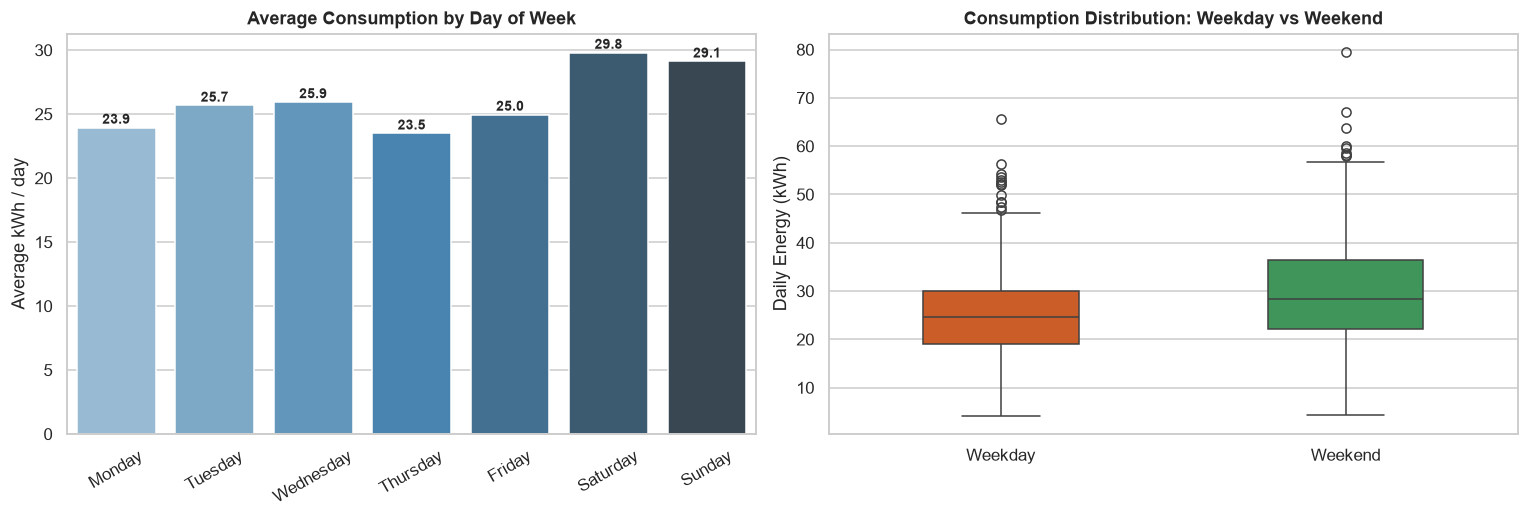

Weekday Average : 24.80 kWh/day
Weekend Average : 29.46 kWh/day
Weekend Premium : +18.8% higher consumption on weekends


In [9]:
# Visualization 4: Day of Week Analysis & Weekday vs Weekend Comparison
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Subplot 1: Day of Week Bar Chart
dow_avg = daily_df.groupby("Day_Name")["Daily_Energy_kWh"].mean().reindex(day_order)
sns.barplot(x=dow_avg.index, y=dow_avg.values, ax=axes[0], palette="Blues_d", hue=dow_avg.index, legend=False)
for i, v in enumerate(dow_avg.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9, fontweight='bold')
axes[0].set_title("Average Consumption by Day of Week", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Average kWh / day")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=30)

# Subplot 2: Weekday vs Weekend Boxplot
sns.boxplot(data=daily_df, x="Day_Type", y="Daily_Energy_kWh", order=["Weekday", "Weekend"],
            palette=["#31a354", "#e6550d"], hue="Day_Type", legend=False, ax=axes[1], width=0.45)
axes[1].set_title("Consumption Distribution: Weekday vs Weekend", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Daily Energy (kWh)")
axes[1].set_xlabel("")

wkday_mean = daily_df[daily_df["Day_Type"] == "Weekday"]["Daily_Energy_kWh"].mean()
wkend_mean = daily_df[daily_df["Day_Type"] == "Weekend"]["Daily_Energy_kWh"].mean()
diff_pct = ((wkend_mean - wkday_mean) / wkday_mean) * 100

plt.tight_layout()
plt.show()
print(f"Weekday Average : {wkday_mean:.2f} kWh/day")
print(f"Weekend Average : {wkend_mean:.2f} kWh/day")
print(f"Weekend Premium : +{diff_pct:.1f}% higher consumption on weekends")


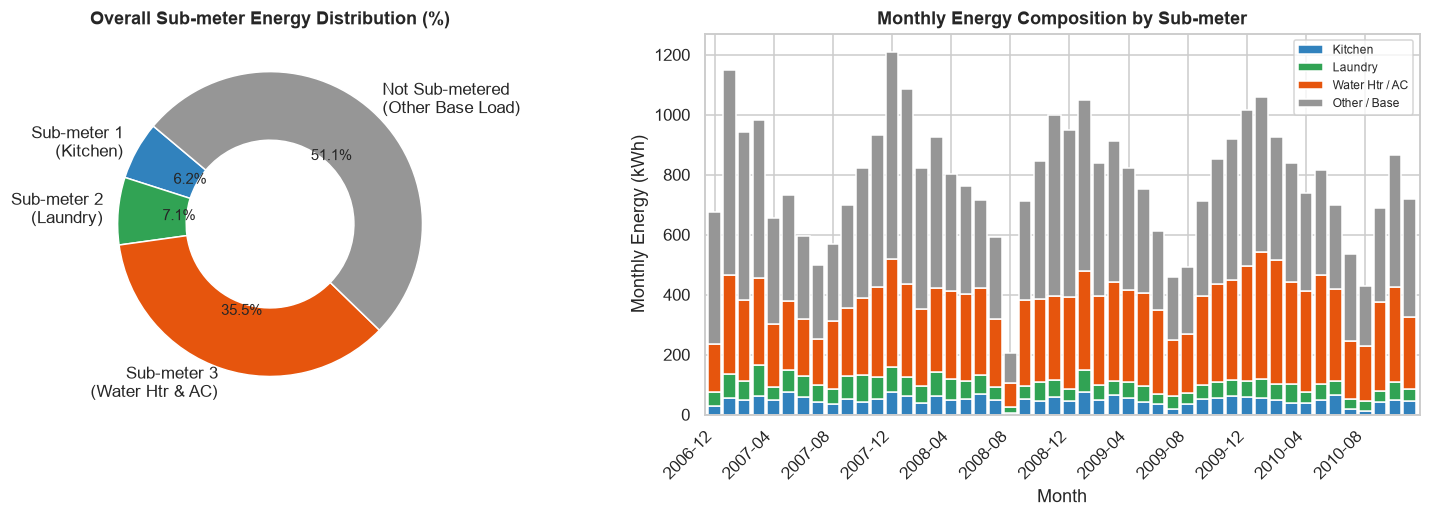

Cumulative Sub-meter Totals:
  - Sub-meter 1 (Kitchen)              :   2,320.2 kWh (6.2%)
  - Sub-meter 2 (Laundry)              :   2,687.9 kWh (7.1%)
  - Sub-meter 3 (Water Htr & AC)       :  13,374.2 kWh (35.5%)
  - Not Sub-metered (Other Base Load)  :  19,247.4 kWh (51.1%)


In [10]:
# Visualization 5: Sub-meter Load Breakdown
sub_totals = {
    "Sub-meter 1\n(Kitchen)": daily_df["Sub_metering_1_kWh"].sum(),
    "Sub-meter 2\n(Laundry)": daily_df["Sub_metering_2_kWh"].sum(),
    "Sub-meter 3\n(Water Htr & AC)": daily_df["Sub_metering_3_kWh"].sum(),
    "Not Sub-metered\n(Other Base Load)": daily_df["Other_kWh"].sum(),
}
tot_sum = sum(sub_totals.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Donut chart
colors = ["#3182bd", "#31a354", "#e6550d", "#969696"]
axes[0].pie(sub_totals.values(), labels=sub_totals.keys(), autopct='%1.1f%%',
            startangle=140, colors=colors, wedgeprops=dict(width=0.45, edgecolor='w'))
axes[0].set_title("Overall Sub-meter Energy Distribution (%)", fontsize=12, fontweight='bold')

# Monthly stacked bar chart
sub_cols = ["Sub_metering_1_kWh", "Sub_metering_2_kWh", "Sub_metering_3_kWh", "Other_kWh"]
renamed_cols = {
    "Sub_metering_1_kWh": "Kitchen",
    "Sub_metering_2_kWh": "Laundry",
    "Sub_metering_3_kWh": "Water Htr / AC",
    "Other_kWh": "Other / Base"
}
m_sub = monthly_df.set_index("Month")[sub_cols].rename(columns=renamed_cols)
m_sub.plot(kind="bar", stacked=True, ax=axes[1], width=0.85, color=colors)
axes[1].set_title("Monthly Energy Composition by Sub-meter", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Monthly Energy (kWh)")
axes[1].set_xticks(range(0, len(m_sub), 4))
axes[1].set_xticklabels(m_sub.index[::4], rotation=45, ha='right')
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print("Cumulative Sub-meter Totals:")
for k, v in sub_totals.items():
    print(f"  - {k.replace(chr(10), ' '):<35}: {v:>9,.1f} kWh ({100*v/tot_sum:.1f}%)")


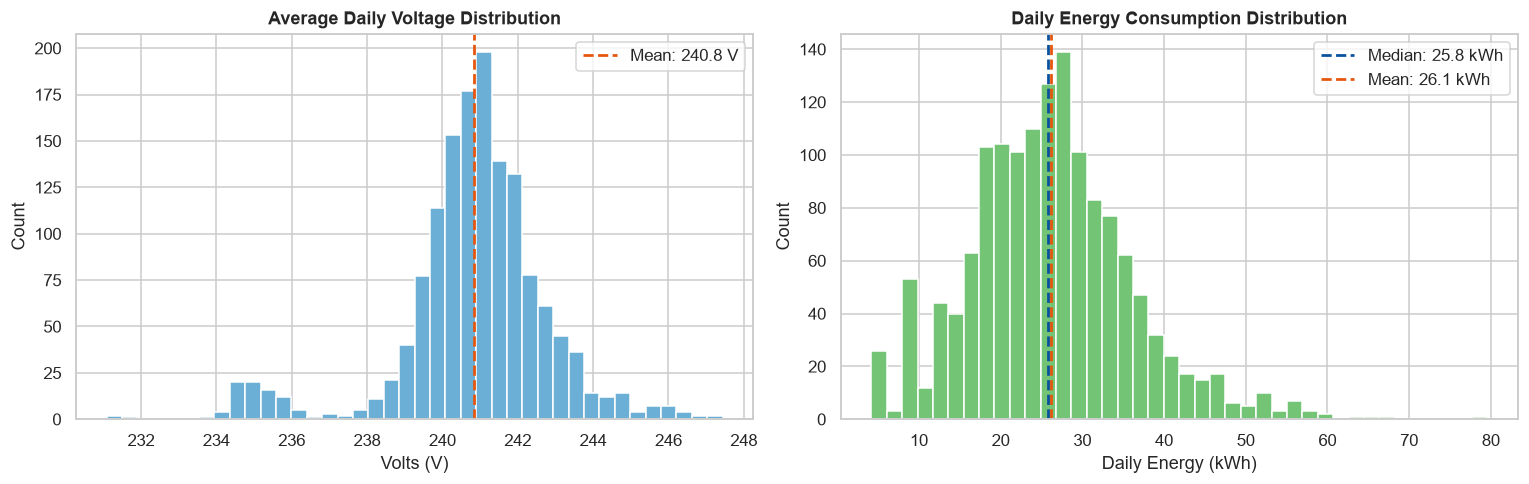

In [11]:
# Visualization 6: Voltage & Global Active Power Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(daily_df["Avg_Voltage"], bins=40, color="#6baed6", edgecolor="white")
axes[0].axvline(daily_df["Avg_Voltage"].mean(), color="#e6550d", ls="--", lw=1.8, 
                label=f"Mean: {daily_df['Avg_Voltage'].mean():.1f} V")
axes[0].set_title("Average Daily Voltage Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Volts (V)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(daily_df["Daily_Energy_kWh"], bins=40, color="#74c476", edgecolor="white")
axes[1].axvline(daily_df["Daily_Energy_kWh"].median(), color="#08519c", ls="--", lw=1.8,
                label=f"Median: {daily_df['Daily_Energy_kWh'].median():.1f} kWh")
axes[1].axvline(daily_df["Daily_Energy_kWh"].mean(), color="#e6550d", ls="--", lw=1.8,
                label=f"Mean: {daily_df['Daily_Energy_kWh'].mean():.1f} kWh")
axes[1].set_title("Daily Energy Consumption Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Daily Energy (kWh)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


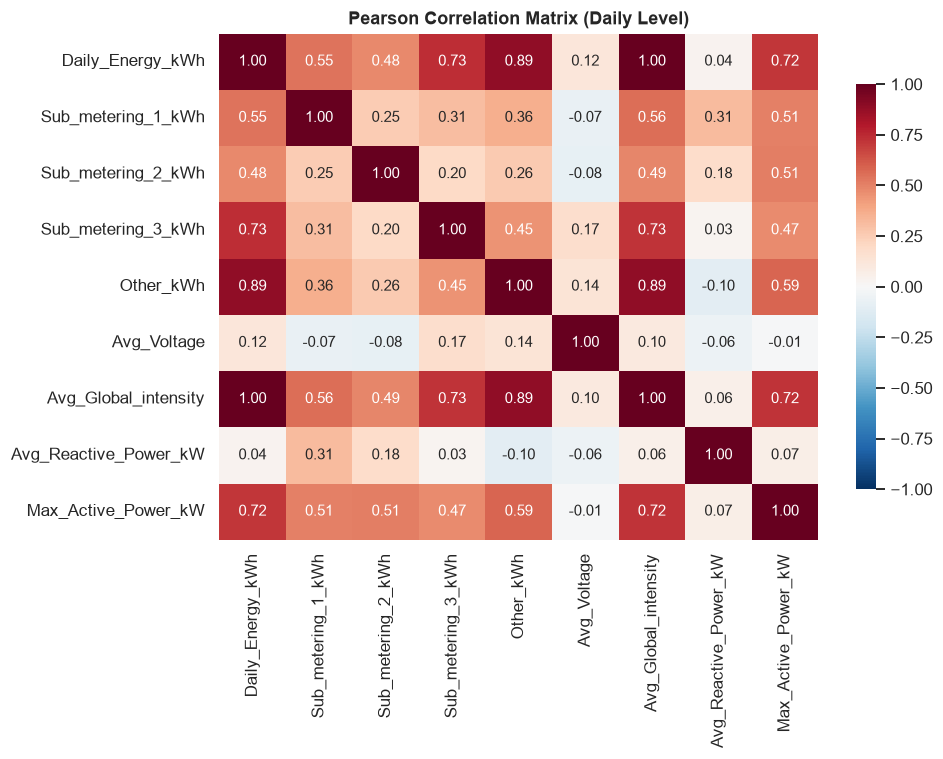

In [12]:
# Visualization 7: Correlation Heatmap Across Daily Metrics
corr_cols = ["Daily_Energy_kWh", "Sub_metering_1_kWh", "Sub_metering_2_kWh", "Sub_metering_3_kWh",
             "Other_kWh", "Avg_Voltage", "Avg_Global_intensity", "Avg_Reactive_Power_kW", "Max_Active_Power_kW"]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(daily_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title("Pearson Correlation Matrix (Daily Level)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


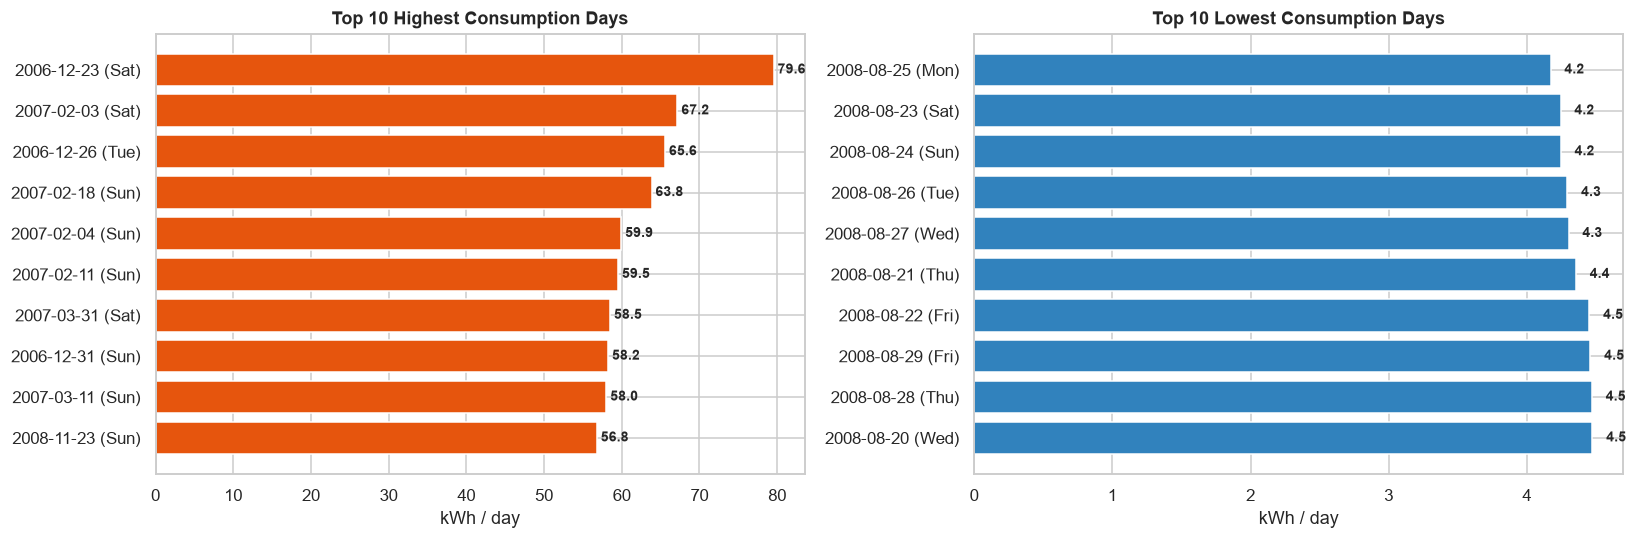

In [13]:
# Visualization 8: Top 10 Highest & Lowest Consumption Days
top10 = daily_df.nlargest(10, "Daily_Energy_kWh").sort_values("Daily_Energy_kWh")
bot10 = daily_df.nsmallest(10, "Daily_Energy_kWh").sort_values("Daily_Energy_kWh", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 10 High
top_labels = top10["Date"].dt.strftime("%Y-%m-%d (%a)")
axes[0].barh(top_labels, top10["Daily_Energy_kWh"], color="#e6550d")
for i, v in enumerate(top10["Daily_Energy_kWh"]):
    axes[0].text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=9, fontweight='bold')
axes[0].set_title("Top 10 Highest Consumption Days", fontsize=12, fontweight='bold')
axes[0].set_xlabel("kWh / day")

# Top 10 Low
bot_labels = bot10["Date"].dt.strftime("%Y-%m-%d (%a)")
axes[1].barh(bot_labels, bot10["Daily_Energy_kWh"], color="#3182bd")
for i, v in enumerate(bot10["Daily_Energy_kWh"]):
    axes[1].text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=9, fontweight='bold')
axes[1].set_title("Top 10 Lowest Consumption Days", fontsize=12, fontweight='bold')
axes[1].set_xlabel("kWh / day")

plt.tight_layout()
plt.show()


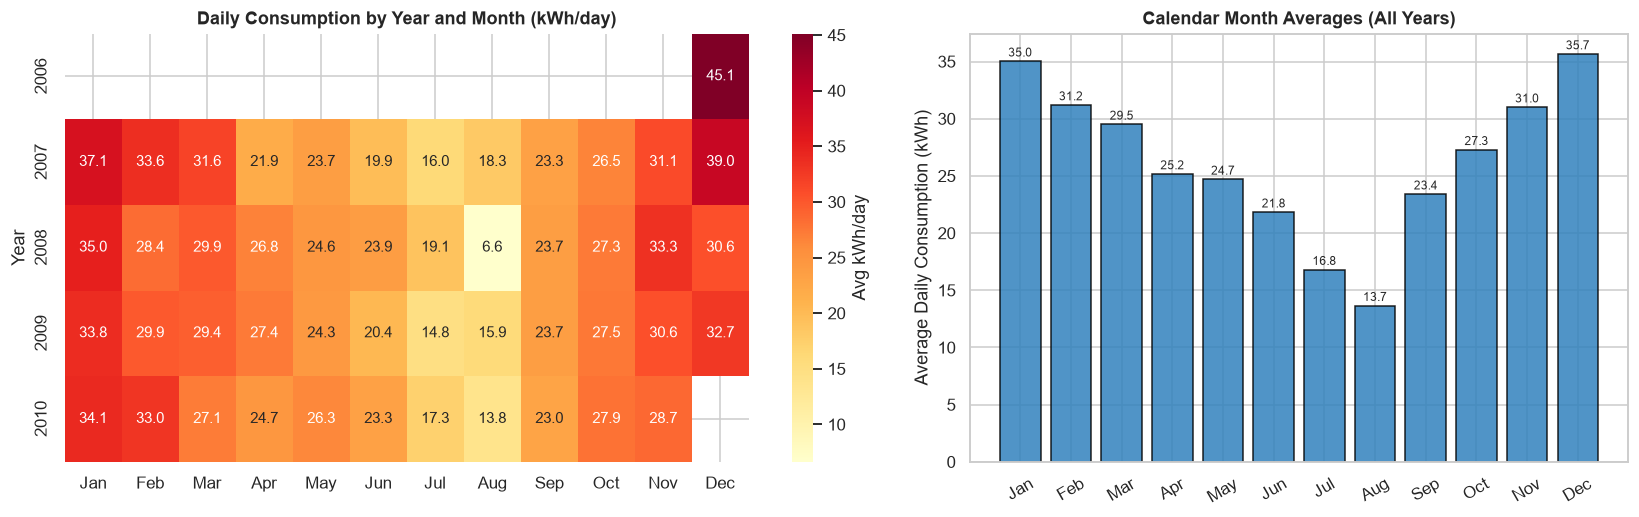

Peak Month   : December (35.66 kWh/day)
Lowest Month : August   (13.67 kWh/day)


In [14]:
# Visualization 9: Seasonal Patterns & Calendar Month Heatmap
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
piv = daily_df.pivot_table(index="Year", columns="Month", values="Daily_Energy_kWh", aggfunc="mean")
piv.columns = [month_names[m - 1] for m in piv.columns]
cal_avg = daily_df.groupby("Month")["Daily_Energy_kWh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={'width_ratios': [1.3, 1]})

sns.heatmap(piv, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0], cbar_kws={'label': 'Avg kWh/day'})
axes[0].set_title("Daily Consumption by Year and Month (kWh/day)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("")

axes[1].bar(month_names, cal_avg.values, color="#3182bd", edgecolor="black", alpha=0.85)
for i, v in enumerate(cal_avg.values):
    axes[1].text(i, v + 0.4, f"{v:.1f}", ha="center", fontsize=8)
axes[1].set_title("Calendar Month Averages (All Years)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Average Daily Consumption (kWh)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"Peak Month   : December ({cal_avg.max():.2f} kWh/day)")
print(f"Lowest Month : August   ({cal_avg.min():.2f} kWh/day)")


## 7. Relational SQL Analysis (SQLite)

We load the aggregated `daily_energy` dataset into an embedded SQLite database (`energy.db`) and run the project's analytical SQL queries defined in `sql/energy_analysis.sql`. These queries demonstrate data aggregation, ranking, and time-series window functions:
- Overall consumption KPIs (sum, average, min, max)
- Monthly consumption breakdowns
- Top 10 highest and bottom 10 lowest consumption days
- Day-over-day changes using `LAG()`
- 7-day moving averages using SQL window framing
- Annual consumption rankings using `RANK() OVER (PARTITION BY Year ORDER BY Daily_Energy_kWh DESC)`


In [15]:
# Initialize SQLite database and populate table `daily_energy`
conn = sql_analysis.build_database(cfg.POWERBI_DIR / "daily_energy.csv", cfg.DB_PATH)
queries = sql_analysis.parse_queries(cfg.SQL_FILE)
print(f"Database ready at: {cfg.DB_PATH}")
print(f"Loaded {len(queries)} analytical queries from {cfg.SQL_FILE.name}")


Database ready at: D:\Smart Energy Monitoring\Final Output\Smart-Household-Energy-Analytics\Smart-Household-Energy-Analytics\data\processed\energy.db
Loaded 16 analytical queries from energy_analysis.sql


In [16]:
# Execute Query 1: Total Energy & Days Analyzed
q_total = dict(queries)["q01_total_energy"]
res_total = pd.read_sql_query(q_total, conn)
display(res_total)

# Execute Query 6: Top 10 Consumption Days
q_top10 = dict(queries)["q06_top10_consumption_days"]
res_top10 = pd.read_sql_query(q_top10, conn)
print("\n--- Top 10 Highest Consumption Days ---")
display(res_top10)

# Execute Query 8: Weekday vs Weekend Comparison
q_wk = dict(queries)["q08_weekday_vs_weekend"]
res_wk = pd.read_sql_query(q_wk, conn)
print("\n--- Weekday vs Weekend Summary ---")
display(res_wk)

# Execute Query 11b: Day-on-Day Change via LAG() Window Function
q_lag = dict(queries)["q11b_biggest_day_on_day_increases"]
res_lag = pd.read_sql_query(q_lag, conn)
print("\n--- Top Day-on-Day Energy Increases (SQL LAG Function) ---")
display(res_lag)


,Total_Energy_kWh,Days_Analysed
0,37629.72,1440



--- Top 10 Highest Consumption Days ---


,Date,Day_Name,Daily_Energy_kWh
0,2006-12-23,Saturday,79.56
1,2007-02-03,Saturday,67.16
2,2006-12-26,Tuesday,65.57
3,2007-02-18,Sunday,63.83
4,2007-02-04,Sunday,59.93
5,2007-02-11,Sunday,59.52
6,2007-03-31,Saturday,58.49
7,2006-12-31,Sunday,58.24
8,2007-03-11,Sunday,58.01
9,2007-01-21,Sunday,56.79



--- Weekday vs Weekend Summary ---


,Day_Type,Days,Avg_Daily_Energy_kWh,Min_Daily_Energy_kWh,Max_Daily_Energy_kWh
0,Weekday,1029,24.80,4.17,65.57
1,Weekend,411,29.46,4.24,79.56



--- Top Day-on-Day Energy Increases (SQL LAG Function) ---


,Date,Previous_Day_kWh,Daily_Energy_kWh,Increase_kWh
0,2006-12-23,39.02,79.56,40.53
1,2007-02-03,27.80,67.16,39.37
2,2007-01-04,16.90,54.32,37.42
3,2007-03-31,23.37,58.49,35.12
4,2007-02-18,34.62,63.83,29.21
5,2008-12-27,20.40,49.54,29.14
6,2007-01-13,24.35,53.11,28.76
7,2008-11-23,28.52,56.79,28.27
8,2010-10-18,17.46,45.23,27.78
9,2007-03-24,21.82,49.47,27.66


## 8. Feature Engineering & Zero-Leakage Validation

### Problem Formulation:
We formulate a **next-day daily energy forecasting** problem:
- **As-of Day $t$:** At the conclusion of day $t$, we observe all historical data up to and including day $t$.
- **Target Variable:** $Y_{t+1} = \text{Next\_Day\_Energy\_kWh}$ (total active energy consumed on calendar day $t+1$).
- **Features Extracted at Day $t$:**
  1. `Energy_Today`: Energy consumed on day $t$.
  2. **Autoregressive Lags:** `Lag_1`, `Lag_2`, `Lag_3`, `Lag_7`, `Lag_14`, `Lag_30` (capturing yesterday, weekly periodicity, and bi-weekly/monthly history).
  3. **Rolling Averages:** `Rolling_Mean_3`, `Rolling_Mean_7`, `Rolling_Mean_14`, `Rolling_Mean_30` (capturing short-term baseline momentum).
  4. **Rolling Volatility:** `Rolling_Std_7`, `Rolling_Std_30` (capturing consumption variability).
  5. **Calendar Context of Target Day:** `Target_DayOfWeek`, `Target_IsWeekend`, `Target_Month`. Because calendar properties of tomorrow are strictly known in advance, including them is valid and causes zero leakage.

### Leakage Verification Protocol:
To prove zero lookahead leakage, we conduct an explicit consistency test: modifying all future consumption values after day $t$ must leave the feature vector at day $t$ completely unchanged.


In [17]:
# Build feature table
daily_for_features = fc.load_daily()
feats_df = fc.build_features(daily_for_features)

# Run strict programmatic leakage test
fc.check_feature_consistency(feats_df, daily_for_features)

# Drop initial burn-in period (first 30 days due to 30-day lags/rolling windows) and the final day (no tomorrow)
model_data = feats_df.dropna(subset=fc.FEATURES + [fc.TARGET]).reset_index(drop=True)

print(f"Total Model-Ready Rows : {len(model_data):,}")
print(f"Input Feature Dimensions: {len(fc.FEATURES)} features ({len(fc.NUMERIC)} numeric, {len(fc.CALENDAR)} calendar)")
print("\nFeature Schema:")
print("Numeric :", fc.NUMERIC)
print("Calendar:", fc.CALENDAR)
display(model_data[['Date', 'Target_Date', 'Energy_Today', 'Lag_1', 'Lag_7', 'Rolling_Mean_7', 'Target_DayOfWeek', 'Next_Day_Energy_kWh']].head(3))


Leakage check passed: features at day t are unchanged when all later days are altered.
Total Model-Ready Rows : 1,409
Input Feature Dimensions: 16 features (13 numeric, 3 calendar)

Feature Schema:
Numeric : ['Energy_Today', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30', 'Rolling_Mean_3', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Mean_30', 'Rolling_Std_7', 'Rolling_Std_30']
Calendar: ['Target_DayOfWeek', 'Target_IsWeekend', 'Target_Month']


,Date,Target_Date,Energy_Today,Lag_1,Lag_7,Rolling_Mean_7,Target_DayOfWeek,Next_Day_Energy_kWh
0,2007-01-16,2007-01-17,28.10673,35.81130,31.15090,37.867179,2,47.46147
1,2007-01-17,2007-01-18,47.46147,28.10673,35.91333,39.516913,3,30.35770
2,2007-01-18,2007-01-19,30.35770,47.46147,37.58657,38.484217,4,24.67400


### Chronological Train / Test Partition (80 / 20)

For time-series forecasting, standard random cross-validation or randomized train-test splits must **never** be used, as shuffling observations leaks future temporal autocorrelations into the training set. We perform an 80/20 **chronological split**:
- **Training Set (80%):** 1,127 observations (Target dates: 2007-01-17 to 2010-02-16)
- **Hold-out Test Set (20%):** 282 observations (Target dates: 2010-02-17 to 2010-11-25)


In [18]:
# Execute chronological split
train_df, test_df = fc.chronological_split(model_data, train_frac=0.8)

print(f"Training Partition : {train_df['Target_Date'].min().strftime('%Y-%m-%d')} to {train_df['Target_Date'].max().strftime('%Y-%m-%d')} ({len(train_df)} days)")
print(f"Testing Partition  : {test_df['Target_Date'].min().strftime('%Y-%m-%d')} to {test_df['Target_Date'].max().strftime('%Y-%m-%d')} ({len(test_df)} days)")
print(f"Test Set Mean Target: {test_df[fc.TARGET].mean():.2f} kWh/day (Std: {test_df[fc.TARGET].std():.2f} kWh/day)")


Training Partition : 2007-01-17 to 2010-02-16 (1127 days)
Testing Partition  : 2010-02-17 to 2010-11-25 (282 days)
Test Set Mean Target: 23.74 kWh/day (Std: 7.35 kWh/day)


## 9. Model Development & Training

We develop and train four distinct models:
1. **Naive Baseline (Persistence):** Predicts tomorrow's energy will equal today's energy ($\hat{Y}_{t+1} = Y_t$). Serves as the critical benchmark.
2. **Linear Regression Pipeline:** Standardizes numeric variables with `StandardScaler` and one-hot encodes calendar attributes (`Target_DayOfWeek`, `Target_Month`) with `OneHotEncoder`.
3. **Random Forest Regressor:** Non-linear ensemble model with 300 estimators, max tree depth 8, and min samples leaf 5 (`random_state=42`).
4. **XGBoost Regressor:** Gradient-boosted decision trees with 300 estimators, learning rate 0.05, max tree depth 3, subsample 0.8, and colsample 0.8 (`random_state=42`).


In [19]:
# Instantiate model dictionary
models_dict = fc.make_models()
for name, m in models_dict.items():
    print(f"Initialized model: {name}")

# Fit models on the training set and evaluate on test set
comp_df, comp_obs_df, preds_dict, fitted_models = fc.evaluate_all(train_df, test_df)

print("\nAll models trained and evaluated successfully!")


Initialized model: Linear Regression
Initialized model: Random Forest
Initialized model: XGBoost



All models trained and evaluated successfully!


## 10. Model Evaluation & Comparative Performance

We evaluate models across four key metrics:
- **Mean Absolute Error (MAE):** Average magnitude of forecasting errors in $kWh$.
- **Root Mean Squared Error (RMSE):** Penalizes larger forecasting errors in $kWh$.
- **Coefficient of Determination ($R^2$):** Proportion of variance in next-day energy explained by the model.
- **Mean Absolute Percentage Error (MAPE):** Relative percentage error.

We also execute a **Sensitivity Analysis** by evaluating performance on the 271 test days whose target day was **not** heavily imputed (excluding 11 heavily imputed days in the test set) to verify that data imputation did not distort model ranking.


In [20]:
# Display Model Performance Comparison Table
print("=" * 75)
print("OVERALL MODEL PERFORMANCE COMPARISON (Hold-Out Test Set: 282 Days)")
print("=" * 75)
display(comp_df.round(4))

print("\n" + "=" * 75)
print("SENSITIVITY ANALYSIS: Non-Heavily Imputed Days Only (271 Days)")
print("=" * 75)
display(comp_obs_df.round(4))

best_model_name = comp_df.loc[comp_df["MAE"].idxmin(), "Model"]
naive_mae = comp_df.loc[comp_df["Model"].str.contains("Naive"), "MAE"].values[0]
best_mae = comp_df.loc[comp_df["Model"] == best_model_name, "MAE"].values[0]
improvement_pct = ((naive_mae - best_mae) / naive_mae) * 100

print(f"\nTop Performing Model: {best_model_name}")
print(f"MAE Improvement over Naive Baseline: {improvement_pct:.2f}% (Reduced from {naive_mae:.2f} to {best_mae:.2f} kWh)")


OVERALL MODEL PERFORMANCE COMPARISON (Hold-Out Test Set: 282 Days)


,Model,MAE,RMSE,R2,MAPE
0,Naive Baseline (previous day),4.5617,6.4846,0.2192,19.3729
1,Linear Regression,4.1376,5.6579,0.4056,19.6592
2,Random Forest,3.9644,5.3373,0.4711,18.7275
3,XGBoost,3.8164,5.2281,0.4925,17.6837



SENSITIVITY ANALYSIS: Non-Heavily Imputed Days Only (271 Days)


,Model,Test_Rows,MAE,RMSE,R2,MAPE
0,Naive Baseline (previous day),271,4.6718,6.5974,0.1831,19.7062
1,Linear Regression,271,4.1734,5.7154,0.3869,19.6913
2,Random Forest,271,3.9787,5.3771,0.4574,18.5983
3,XGBoost,271,3.8226,5.2631,0.4801,17.5427



Top Performing Model: XGBoost
MAE Improvement over Naive Baseline: 16.34% (Reduced from 4.56 to 3.82 kWh)


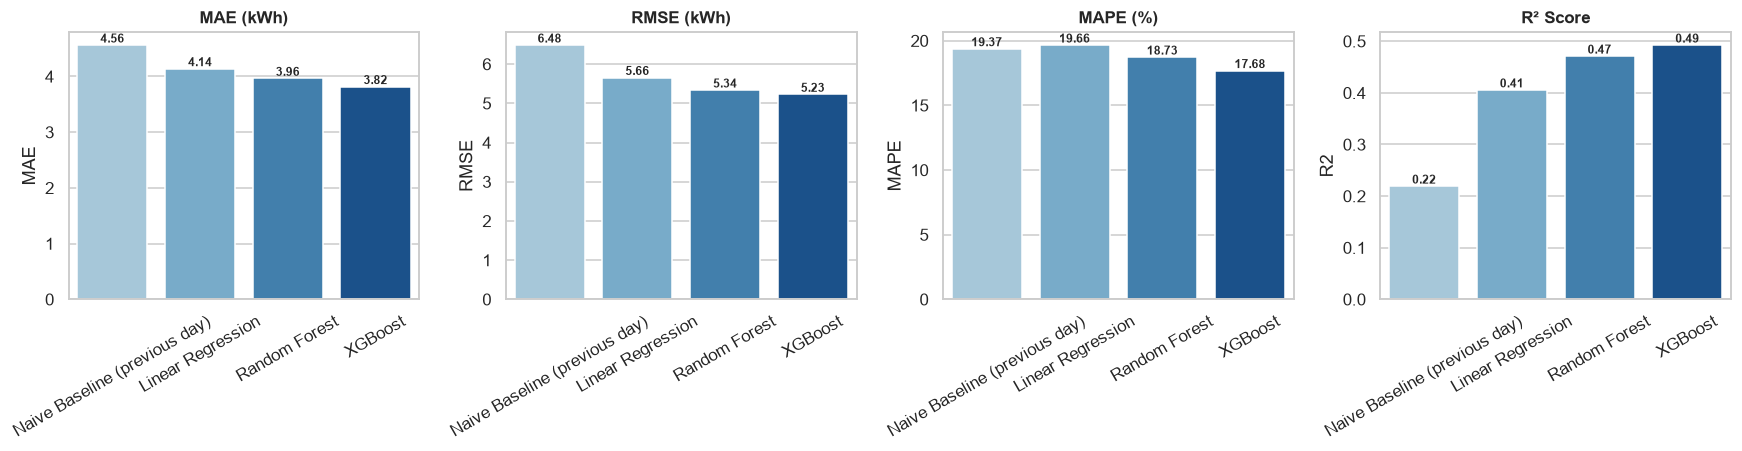

In [21]:
# Visualization: Model Evaluation Metrics Comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
palette = ["#9ecae1", "#6baed6", "#3182bd", "#08519c"]

for ax, metric, title in zip(axes, ["MAE", "RMSE", "MAPE", "R2"], 
                             ["MAE (kWh)", "RMSE (kWh)", "MAPE (%)", "R² Score"]):
    sns.barplot(data=comp_df, x="Model", y=metric, ax=ax, palette=palette, hue="Model", legend=False)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


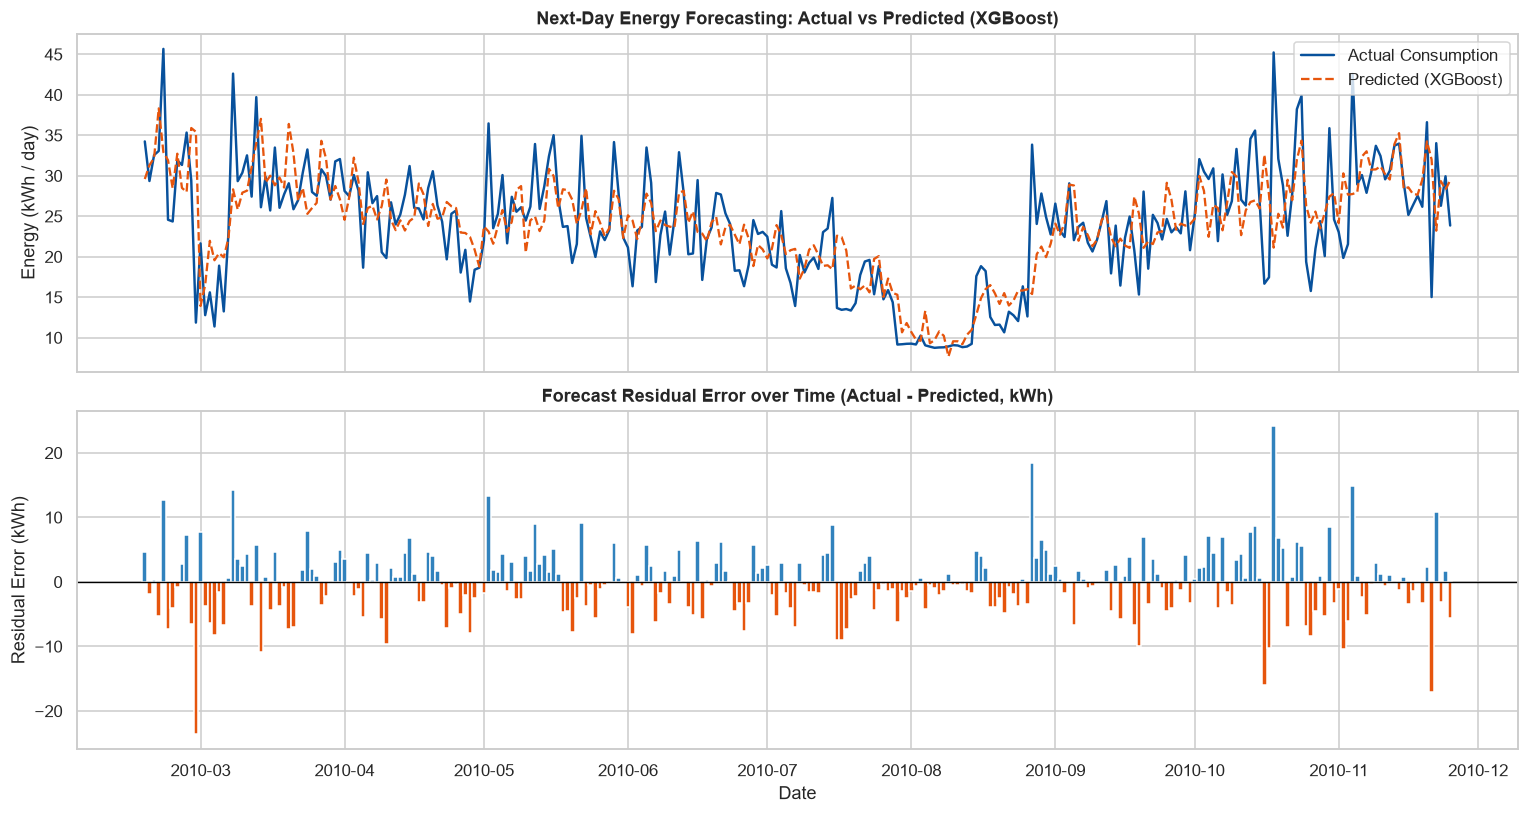

In [22]:
# Visualization: Actual vs Predicted Energy & Residual Error Analysis
best_preds = preds_dict[best_model_name]
res_table = fc.prediction_table(test_df, best_preds, best_model_name)
dates_test = pd.to_datetime(res_table["Date"])

fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), sharex=True)

# Actual vs Predicted Time Series
axes[0].plot(dates_test, res_table["Actual"], color="#08519c", lw=1.6, label="Actual Consumption")
axes[0].plot(dates_test, res_table["Predicted"], color="#e6550d", lw=1.5, ls="--", label=f"Predicted ({best_model_name})")
axes[0].set_title(f"Next-Day Energy Forecasting: Actual vs Predicted ({best_model_name})", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Energy (kWh / day)")
axes[0].legend(loc="upper right", frameon=True)

# Prediction Error Over Time
error_colors = np.where(res_table["Error"] >= 0, "#3182bd", "#e6550d")
axes[1].bar(dates_test, res_table["Error"], color=error_colors, width=1.0)
axes[1].axhline(0, color="black", lw=0.9, ls="-")
axes[1].set_title("Forecast Residual Error over Time (Actual - Predicted, kWh)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Residual Error (kWh)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


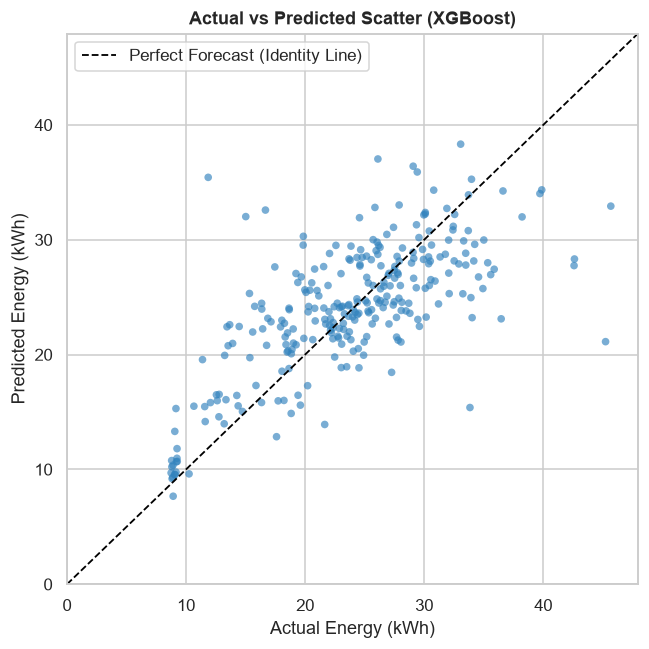

In [23]:
# Scatter Plot: Actual vs Predicted with Identity Line
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(res_table["Actual"], res_table["Predicted"], color="#3182bd", alpha=0.65, edgecolors='none', s=25)
max_val = max(res_table["Actual"].max(), res_table["Predicted"].max()) * 1.05
ax.plot([0, max_val], [0, max_val], color="black", ls="--", lw=1.2, label="Perfect Forecast (Identity Line)")
ax.set_title(f"Actual vs Predicted Scatter ({best_model_name})", fontsize=12, fontweight='bold')
ax.set_xlabel("Actual Energy (kWh)")
ax.set_ylabel("Predicted Energy (kWh)")
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 11. Feature Importance Analysis

To understand what information drives the predictions, we evaluate:
1. **Tree-Based Feature Importance:** Built-in impurity reduction / gain.
2. **Permutation Importance:** Measures the increase in hold-out test set MAE (in $kWh$) when a feature's values are randomly permuted.


Top 5 Features by Model:


,Model,Feature,Importance,Permutation_Importance_MAE_kWh
0,Random Forest,Rolling_Mean_7,0.298242,0.277433
1,Random Forest,Rolling_Mean_3,0.214875,0.501426
2,Random Forest,Energy_Today,0.116326,0.560171
3,Random Forest,Rolling_Mean_14,0.059423,0.167235
4,Random Forest,Target_DayOfWeek,0.051475,0.009189
16,XGBoost,Rolling_Mean_7,0.243540,0.191422
17,XGBoost,Rolling_Mean_3,0.171890,0.304077
18,XGBoost,Energy_Today,0.093500,0.687291
19,XGBoost,Rolling_Mean_30,0.073657,0.202881
20,XGBoost,Target_DayOfWeek,0.070980,0.186373


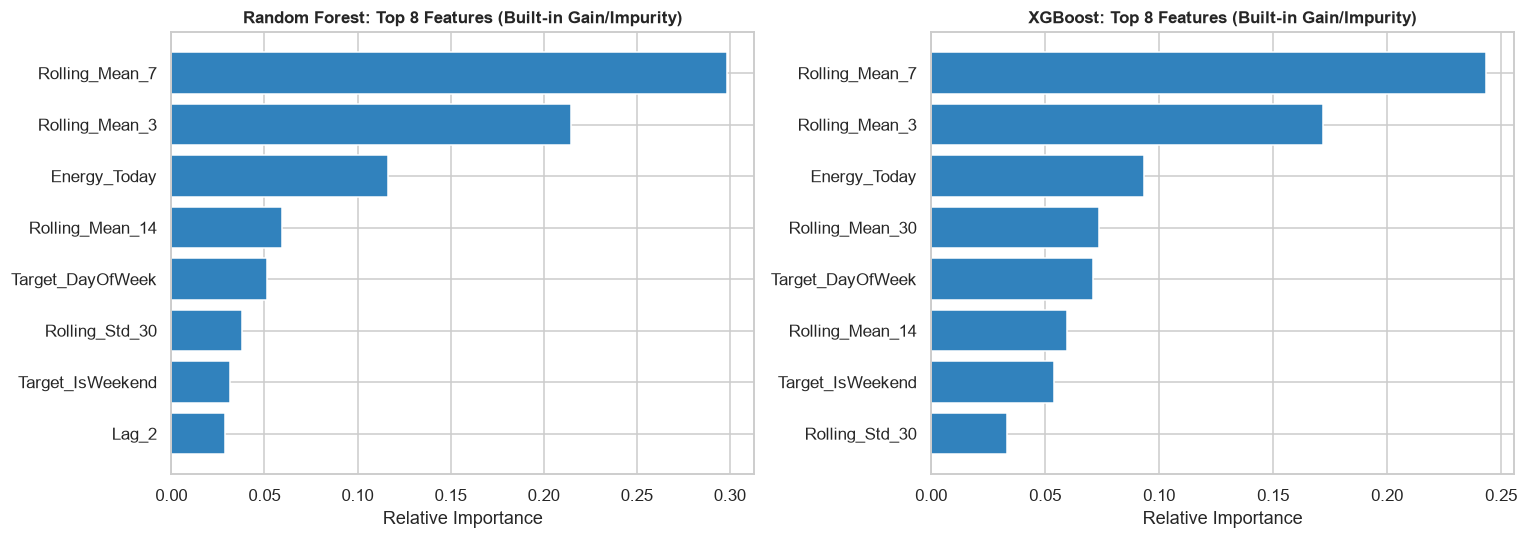

In [24]:
# Calculate Feature Importance table
fi_df = fc.feature_importance_table(fitted_models, test_df[fc.FEATURES], test_df[fc.TARGET])

print("Top 5 Features by Model:")
display(fi_df.groupby("Model").head(5)[["Model", "Feature", "Importance", "Permutation_Importance_MAE_kWh"]])

# Plot Feature Importance Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, model_name in enumerate(["Random Forest", "XGBoost"]):
    sub_fi = fi_df[fi_df["Model"] == model_name].nlargest(8, "Importance").iloc[::-1]
    axes[idx].barh(sub_fi["Feature"], sub_fi["Importance"], color="#3182bd")
    axes[idx].set_title(f"{model_name}: Top 8 Features (Built-in Gain/Impurity)", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()


## 12. Recursive Multi-Step 7-Day Forecasting

After validating model performance, we refit the best ML model on the entire labelled historical dataset (1,409 days up to 2010-11-25) and simulate a **recursive 7-day future forecast** (2010-11-26 to 2010-12-02).
- At day $t+1$, the model forecasts energy $\hat{Y}_{t+1}$.
- This prediction is appended to the historical sequence to construct lags and rolling features for forecasting day $t+2$.
- The process repeats recursively for the full 7-day horizon without using future ground truth.


In [25]:
# Refit final model on all historical data
best_ml_name = comp_df[comp_df["Model"] != "Naive Baseline (previous day)"].sort_values("MAE").iloc[0]["Model"]
final_model = clone(fc.make_models()[best_ml_name]).fit(model_data[fc.FEATURES], model_data[fc.TARGET])

# Save serialized model artifact
joblib.dump(final_model, cfg.FORECAST_DIR / "final_forecast_model.joblib")
print(f"Refit {best_ml_name} on all {len(model_data)} rows and saved to {cfg.FORECAST_DIR / 'final_forecast_model.joblib'}")

# Generate recursive 7-day forecast
forecast_7d = fc.forecast_next_days(final_model, daily_df.set_index("Date")["Daily_Energy_kWh"], n_days=7)
forecast_7d["Model"] = best_ml_name

print("\n--- Recursive 7-Day Forecast (2010-11-26 to 2010-12-02) ---")
display(forecast_7d.round(3))


Refit XGBoost on all 1409 rows and saved to D:\Smart Energy Monitoring\Final Output\Smart-Household-Energy-Analytics\Smart-Household-Energy-Analytics\outputs\forecasts\final_forecast_model.joblib

--- Recursive 7-Day Forecast (2010-11-26 to 2010-12-02) ---


,Date,Horizon_Day,Forecasted_Energy_kWh,Model
0,2010-11-26,1,27.826,XGBoost
1,2010-11-27,2,31.478,XGBoost
2,2010-11-28,3,28.580,XGBoost
3,2010-11-29,4,26.953,XGBoost
4,2010-11-30,5,30.052,XGBoost
5,2010-12-01,6,31.190,XGBoost
6,2010-12-02,7,29.172,XGBoost


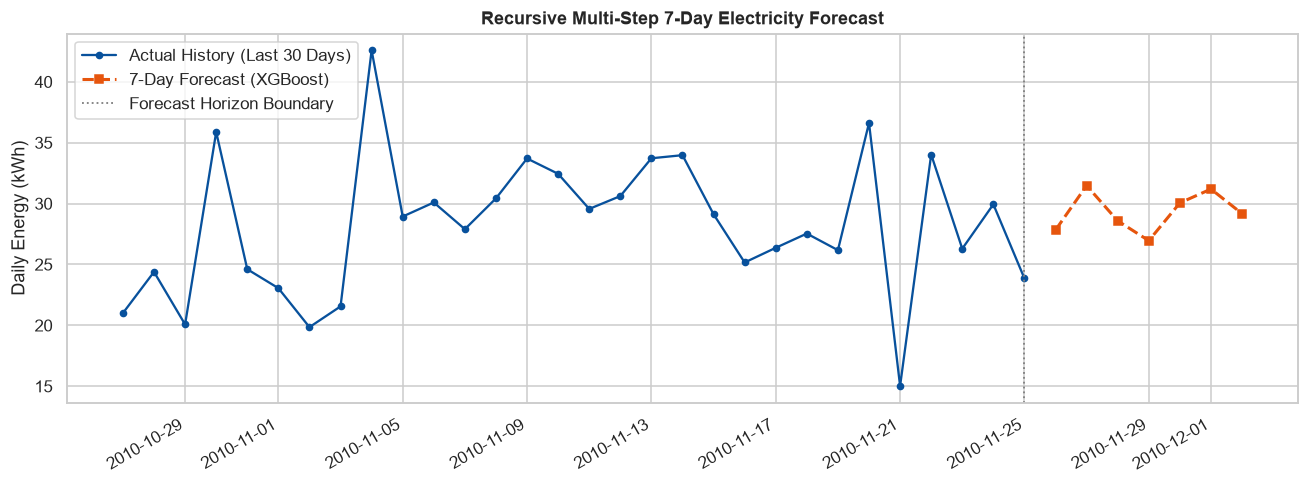

In [26]:
# Visualization: Recent 30 Days and 7-Day Forecast Horizon
fig, ax = plt.subplots(figsize=(12, 4.5))
recent_30 = daily_df.tail(30)

ax.plot(recent_30["Date"], recent_30["Daily_Energy_kWh"], marker="o", ms=4, color="#08519c", label="Actual History (Last 30 Days)")
fc_dates = pd.to_datetime(forecast_7d["Date"])
ax.plot(fc_dates, forecast_7d["Forecasted_Energy_kWh"], marker="s", ms=5, color="#e6550d", ls="--", lw=2, label=f"7-Day Forecast ({best_ml_name})")

ax.axvline(recent_30["Date"].iloc[-1], color="grey", ls=":", lw=1.2, label="Forecast Horizon Boundary")
ax.set_title("Recursive Multi-Step 7-Day Electricity Forecast", fontsize=12, fontweight='bold')
ax.set_ylabel("Daily Energy (kWh)")
ax.legend(loc="upper left", frameon=True)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 13. Energy Consumption Insights & Discussion

Based on our exploratory data analysis, relational SQL findings, and machine learning models, we synthesize key operational conclusions:

1. **Evening Load Peak:** Across the four-year dataset, electrical consumption peaks sharply between **19:00 and 21:00** (averaging 1.89 kWh/hour at 20:00 vs 0.44 kWh/hour at 04:00). Residential demand management initiatives (such as dynamic time-of-use tariffs) should incentivize shifting discretionary appliance loads (dishwashers, washing machines) away from the 19:00–21:00 peak.
2. **Weekend Demand Surge:** Household electricity consumption is **18.8% higher on weekends** (29.46 kWh/day) compared to weekdays (24.80 kWh/day). Saturdays and Sundays demonstrate flatter midday load plateaus due to prolonged household occupancy.
3. **Appliance-Level Dominance:**
   - Sub-meter 3 (electric water heater and air conditioner) accounts for **35.5%** of cumulative energy (13,374 kWh).
   - Sub-meter 2 (laundry/refrigeration) accounts for **7.1%** (2,688 kWh).
   - Sub-meter 1 (kitchen cooking appliances) accounts for **6.2%** (2,320 kWh).
   - **51.1% of total consumption is unmetered baseline load** (lighting, electronics, space heating, auxiliary wall plugs).
4. **Pronounced Seasonality:** Daily energy consumption exhibits strong winter peaks (December average: 35.66 kWh/day) and summer troughs (August average: 13.67 kWh/day), indicating significant space heating and water heating loads during colder months.
5. **Predictive Performance:** XGBoost outperformed all candidate models with a test set MAE of **3.82 kWh/day** (16.3% improvement over the Naive Baseline's 4.56 kWh/day). Short-term rolling means (`Rolling_Mean_7`, `Rolling_Mean_3`) and today's energy (`Energy_Today`) proved to be the most influential predictive features.


## 14. Conclusion & Generated Artifacts

This implementation provides an end-to-end, reproducible workflow that takes raw IoT meter data through time-aware cleaning, feature engineering, SQL analytics, model evaluation, and multi-step forecasting.

### Summary of Generated Deliverables:
- **Cleaned Data Tables (`outputs/powerbi/`):**
  - `cleaned_energy_data.csv`: 2,075,259 imputed and energy-calculated minute rows.
  - `daily_energy.csv`: 1,440 contiguous complete daily aggregations.
  - `hourly_energy.csv`: 34,560 hourly aggregations.
  - `monthly_energy.csv`: 48 monthly aggregations.
  - `weekday_analysis.csv` & `submeter_analysis.csv`: Dimension tables.
  - `forecasting_dataset.csv` & `forecast_results.csv`: Modeling and test evaluation records.
- **Relational SQL Results (`outputs/powerbi/sql_results/`):**
  - 13 query result CSVs and markdown summary report (`outputs/reports/sql_results.md`).
- **Trained Model Artifacts (`outputs/forecasts/`):**
  - `final_forecast_model.joblib`: Serialized XGBoost model.
  - `all_model_predictions.csv` & `model_comparison_excluding_heavily_imputed_days.csv`.
- **High-Resolution Figures (`outputs/plots/`):**
  - 18 publication-quality plots (EDA, SQL metrics, actual vs predicted, feature importance, 7-day forecast).

---
*Notebook completed and verified successfully.*
